<a href="https://colab.research.google.com/github/kruthee05/MACHINELEARNING2/blob/main/baggingBoosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (398, 30)
Shape of X_test: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)


--- Bagging Classifier Performance ---
Accuracy: 0.9591
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



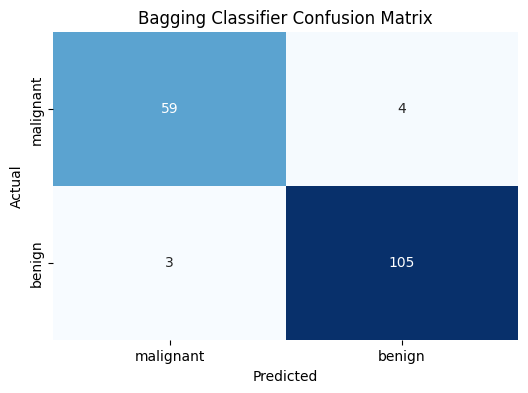

In [3]:
# Initialize and train the Bagging Classifier
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of base estimators
    max_samples=0.8,  # Percentage of samples to draw for each base estimator
    random_state=42,
    n_jobs=-1 # Use all available cores
)
bagging_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bagging = bagging_clf.predict(X_test)

# Evaluate the Bagging Classifier
print("--- Bagging Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_bagging))

# Confusion Matrix
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
plt.title('Bagging Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3. Boosting Classifiers

Boosting is another ensemble method that combines multiple weak learners to create a strong learner. Unlike bagging, boosting builds models sequentially, where each new model attempts to correct the errors of the previous ones. We will implement two popular boosting algorithms: AdaBoost and Gradient Boosting.

#### 3.1 AdaBoost Classifier

AdaBoost (Adaptive Boosting) works by sequentially fitting a series of weak learners (e.g., decision trees) on re-weighted versions of the data. The weights are adjusted at each iteration to give more emphasis to misclassified samples.

--- AdaBoost Classifier Performance ---
Accuracy: 0.9708
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        63
           1       0.99      0.96      0.98       108

    accuracy                           0.97       171
   macro avg       0.96      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



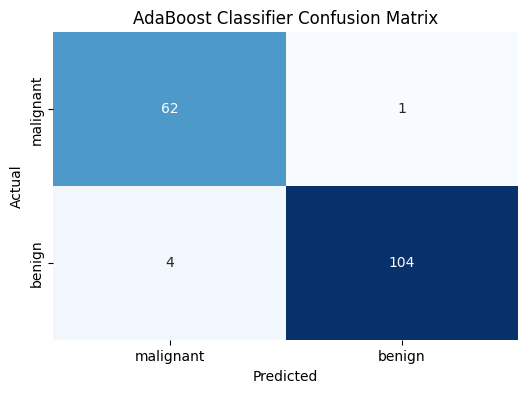

In [4]:
# Initialize and train the AdaBoost Classifier
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42), # Often uses shallow trees
    n_estimators=100, # Number of base estimators
    learning_rate=1.0,
    random_state=42
)
adaboost_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_adaboost = adaboost_clf.predict(X_test)

# Evaluate the AdaBoost Classifier
print("--- AdaBoost Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_adaboost))

# Confusion Matrix
cm_adaboost = confusion_matrix(y_test, y_pred_adaboost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_adaboost, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
plt.title('AdaBoost Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Gradient Boosting Classifier Performance ---
Accuracy: 0.9591
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



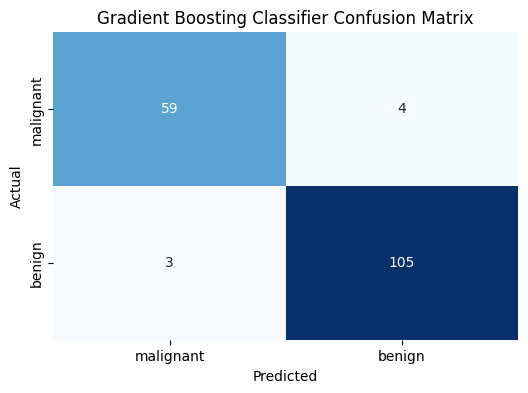

In [5]:
# Initialize and train the Gradient Boosting Classifier
gradient_boost_clf = GradientBoostingClassifier(
    n_estimators=100, # Number of boosting stages
    learning_rate=0.1,
    max_depth=3, # Maximum depth of the individual regression estimators
    random_state=42
)
gradient_boost_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gradient_boost = gradient_boost_clf.predict(X_test)

# Evaluate the Gradient Boosting Classifier
print("--- Gradient Boosting Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boost):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_gradient_boost))

# Confusion Matrix
cm_gradient_boost = confusion_matrix(y_test, y_pred_gradient_boost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gradient_boost, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
plt.title('Gradient Boosting Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Model Performance Comparison ---
                          Model  Accuracy
0            Bagging Classifier    0.9591
1           AdaBoost Classifier    0.9708
2  Gradient Boosting Classifier    0.9591


/tmp/ipykernel_5742/1216752921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis')


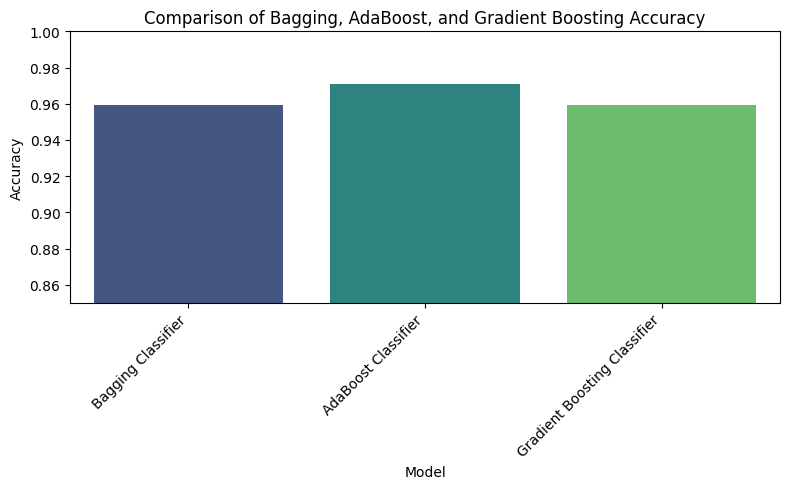

In [6]:
# Calculate accuracies
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
accuracy_gradient_boost = accuracy_score(y_test, y_pred_gradient_boost)

# Create a DataFrame for easy comparison
performance_df = pd.DataFrame({
    'Model': ['Bagging Classifier', 'AdaBoost Classifier', 'Gradient Boosting Classifier'],
    'Accuracy': [accuracy_bagging, accuracy_adaboost, accuracy_gradient_boost]
})

print("--- Model Performance Comparison ---")
print(performance_df.round(4))

# Visualize the comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis')
plt.ylim(0.85, 1.0) # Set a reasonable y-limit for better visualization
plt.title('Comparison of Bagging, AdaBoost, and Gradient Boosting Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()